# omnisea at Bamfield

**Bamfield Marine Sciences Centre**, Barkley Sound, west coast of Vancouver Island.

Within 30 km of the station there is a DFO tide gauge (80 m away), two lighthouse climate
records, and two hydrometric gauges on nearby rivers — four different agencies' APIs, each with
its own field names, units, time conventions and paging rules.

This notebook is one query.

In [1]:
import warnings
warnings.simplefilter("ignore")

import pandas as pd
import omnisea

# A Site is the location type: coordinates, a search radius, and the name you know it by.
# That name travels with the results, so what comes back joins to your own records.
BAMFIELD = omnisea.Site(48.8353, -125.1358, "Bamfield Marine Sciences Centre", radius_km=30)
WEEK = ("2024-07-01", "2024-07-08")

omnisea.sources()

['cioos_metadata',
 'dfo_tides',
 'eccc_ahccd_annual',
 'eccc_ahccd_monthly',
 'eccc_ahccd_seasonal',
 'eccc_climate',
 'eccc_climate_daily',
 'eccc_climate_monthly',
 'eccc_hydrometric',
 'eccc_hydrometric_annual',
 'eccc_hydrometric_annual_peaks',
 'eccc_hydrometric_daily',
 'eccc_hydrometric_monthly',
 'eccc_swob',
 'eccc_swob_marine',
 'erddap_griddap',
 'erddap_tabledap']

## 1. Discover — look before you download

`discover()` asks every registered source what it has, and returns a printable estimate.
Nothing is downloaded yet.

This step exists because marine queries quietly become enormous: ECCC's `climate-hourly`
collection reports **276 million rows** unfiltered. The estimate is how you find that out
*before* making the request.

In [2]:
catalog = omnisea.discover(sites=BAMFIELD, time=WEEK)
print(f"{len(catalog)} stations, ~{catalog.n_rows_est:,} rows estimated")
catalog.frame[["source", "station_id", "name", "distance_km", "n_rows_est"]]

37 stations, ~3,922 rows estimated


,source,station_id,name,distance_km,n_rows_est
0,dfo_tides,08545,Bamfield,0.079201,700
1,eccc_climate_monthly,1030610,BAMFIELD WEST,1.062096,0
2,eccc_climate_monthly,1030605,BAMFIELD EAST,1.417396,0
3,eccc_climate_monthly,1030600,BAMFIELD,2.629415,0
4,eccc_hydrometric_daily,08HB076,SUGSAW LAKE NEAR BAMFIELD,3.306717,8
5,eccc_hydrometric_annual_peaks,08HB076,SUGSAW LAKE NEAR BAMFIELD,3.306717,1
6,eccc_hydrometric_annual,08HB076,SUGSAW LAKE NEAR BAMFIELD,3.306717,1
7,eccc_hydrometric_monthly,08HB076,SUGSAW LAKE NEAR BAMFIELD,3.306717,1
8,erddap_tabledap,ioos-gliderdac-dfo-bumblebee998-20240509T1917,IOOS Glider - Southern Line - dfo-bumblebee998...,3.531633,1008
9,eccc_climate_daily,1031316,CAPE BEALE LIGHT,8.031310,7


In [3]:
# BBox is a NamedTuple in OGC order, so no one has to remember which index is which
box = catalog.query.bbox
print(box)
print("south :", box.south)
print("centre:", tuple(round(v, 4) for v in box.centre), "(lat, lon)")

BBox(west=-125.54568384357654, south=48.56550389088264, east=-124.72591615642347, north=49.105096109117355)
south : 48.56550389088264
centre: (48.8353, -125.1358) (lat, lon)


The tide gauge `08545` is 80 m from the research station.

## 2. Narrow it down

`filter()` returns a new catalogue; the original is untouched. `nearest=n` works
**per site**, so a multi-location query can't return five stations at one place and none
at another.

In [4]:
nearest = catalog.filter(nearest=1)
nearest.frame[["source", "station_id", "name", "distance_km"]]

,source,station_id,name,distance_km
0,dfo_tides,08545,Bamfield,0.079201
1,eccc_climate_monthly,1030610,BAMFIELD WEST,1.062096
2,eccc_hydrometric_annual,08HB076,SUGSAW LAKE NEAR BAMFIELD,3.306717
3,eccc_hydrometric_annual_peaks,08HB076,SUGSAW LAKE NEAR BAMFIELD,3.306717
4,eccc_hydrometric_daily,08HB076,SUGSAW LAKE NEAR BAMFIELD,3.306717
5,eccc_hydrometric_monthly,08HB076,SUGSAW LAKE NEAR BAMFIELD,3.306717
6,erddap_tabledap,ioos-gliderdac-dfo-bumblebee998-20240509T1917,IOOS Glider - Southern Line - dfo-bumblebee998...,3.531633
7,eccc_climate_daily,1031316,CAPE BEALE LIGHT,8.031310


In [5]:
# other ways to slice
{
    "within 10 km":      len(catalog.filter(max_distance_km=10)),
    "tide gauges only":  len(catalog.filter(source="dfo_tides")),
    "all ECCC datasets": len(catalog.filter(provider="eccc")),
    "has air temp":      len(catalog.filter(variables="air_temperature")),
}

{'within 10 km': 11,
 'tide gauges only': 6,
 'all ECCC datasets': 28,
 'has air temp': 12}

## 3. Fetch

Now pull it. The result is a plain `xarray.DataTree` — not a subclass, so everything in the
xarray ecosystem works on it.

In [6]:
tree = nearest.fetch()
omnisea.summary(tree)[["node", "station_name", "n_time", "start", "end"]]

,node,station_name,n_time,start,end
0,/in_situ/tides/08545,Bamfield,672,2024-07-01 00:00:00,2024-07-08 00:00:00
1,/predictions/tides_hilo/08545,Bamfield,27,2024-07-01 03:33:00,2024-07-07 22:03:00
2,/in_situ/weather_daily/1031316,CAPE BEALE LIGHT,8,2024-07-01 00:00:00,2024-07-08 00:00:00


Note the node paths. **Observations and predictions live in separate branches**:

- `/in_situ/tides/08545` — what the gauge measured
- `/predictions/tides_hilo/08545` — what the harmonic model predicts

They look identical in a flat table and are not remotely the same thing, so they never
share a node.

In [7]:
tree

<xarray.DataTree>
Group: /
│   Attributes: (12/17)
│       query_start:             2024-07-01T00:00:00+00:00
│       query_end:               2024-07-08T00:00:00+00:00
│       query_bbox:              [-125.54568384357654, 48.56550389088264, -124.72...
│       query_site_names:        Bamfield Marine Sciences Centre
│       query_site_lats:         [48.8353]
│       query_site_lons:         [-125.1358]
│       ...                      ...
│       history:                 2026-08-25T16:34:23+00:00 created by omnisea 0.1.0
│       omnisea_version:         0.1.0
│       n_nodes:                 3
│       n_empty_series_dropped:  6
│       omnisea_empty_stations:  eccc_climate_monthly/1030610, eccc_hydrometric_a...
│       omnisea_source_notes:    eccc_ahccd_annual: covers 1840-01-01 to 2020-12-...
├── Group: /in_situ
│   ├── Group: /in_situ/tides
│   │   └── Group: /in_situ/tides/08545
│   │           Dimensions:                                        (time: 672)
│   │           Coordinates:
│   │             * time                                           (time) datetime64[us] 5kB ...
│   │               latitude                                       float64 8B 48.84
│   │               longitude                                      float64 8B -125.1
│   │               station_id                                     <U5 20B '08545'
│   │               station_name                                   <U8 32B 'Bamfield'
│   │               site                                           <U31 124B 'Bamfield Marine...
│   │           Data variables:
│   │               water_surface_height_above_reference_datum     (time) float64 5kB 2.014 ....
│   │               water_surface_height_above_reference_datum_qc  (time) object 5kB '1' ... '1'
│   │               reviewed                                       (time) int8 672B 1 1 ... 1 1
│   │           Attributes: (12/22)
│   │               Conventions:            CF-1.10
│   │               featureType:            timeSeries
│   │               source_name:            dfo_tides
│   │               institution:            Fisheries and Oceans Canada / Canadian Hydrograph...
│   │               license:                Fisheries and Oceans Canada — Open Government Lic...
│   │               references:             https://open.canada.ca/en/open-government-licence...
│   │               ...                     ...
│   │               summary:                Observed water level
│   │               datum_offset_CGVD2013:  -1.83
│   │               datum_offset_CGVD28:    -2.05
│   │               datum_offset_comment:   Offsets convert chart datum to the named vertical...
│   │               resolution:             FIFTEEN_MINUTES
│   │               distance_from_site_km:  0.079
│   └── Group: /in_situ/weather_daily
│       └── Group: /in_situ/weather_daily/1031316
│               Dimensions:                 (time: 8)
│               Coordinates:
│                 * time                    (time) datetime64[us] 64B 2024-07-01 ... 2024-07-08
│                   latitude                float64 8B 48.79
│                   longitude               float64 8B -125.2
│                   station_id              <U7 28B '1031316'
│                   station_name            <U16 64B 'CAPE BEALE LIGHT'
│                   site                    <U31 124B 'Bamfield Marine Sciences Centre'
│               Data variables:
│                   air_temperature         (time) float64 64B 14.0 14.0 13.8 ... 14.8 17.8 15.8
│                   air_temperature_min     (time) float64 64B 11.5 11.0 11.0 ... 4.0 13.5 11.5
│                   air_temperature_max     (time) float64 64B 16.5 17.0 16.5 ... 25.5 22.0 20.0
│                   precipitation_amount    (time) float64 64B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
│                   rainfall_amount         (time) float64 64B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
│                   snowfall_amount         (time) float64 64B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
│             

## 4. Provenance travels with the data

Every node carries its institution, licence, source URL and vertical datum — including the
offsets needed to convert chart datum to CGVD2013 or CGVD28.

In [8]:
tides = tree["/in_situ/tides/08545"].dataset
{k: tides.attrs[k] for k in
 ["institution", "license", "datum", "datum_offset_CGVD2013", "resolution", "source_url"]}

{'institution': 'Fisheries and Oceans Canada / Canadian Hydrographic Service',
 'license': 'Fisheries and Oceans Canada — Open Government Licence – Canada',
 'datum': 'chart datum (CD)',
 'datum_offset_CGVD2013': -1.83,
 'resolution': 'FIFTEEN_MINUTES',
 'source_url': 'https://api-iwls.dfo-mpo.gc.ca/api/v1/stations/5cebf1e23d0f4a073c4bc062/data?time-series-code=wlo'}

## 5. Nothing is silently dropped or rescaled

Fields with a CF equivalent are renamed and described. Fields without one still travel,
under the provider's own name, tagged `omnisea_mapped = 0`. QC flags are kept as `<var>_qc`.

In [9]:
# `fields()` is the honest inventory of a result: everything that came back,
# and what omnisea knows about each one.
inventory = omnisea.fields(tree)
inventory.groupby(["source", "kind"]).size().to_frame("n")

n
source             kind      
dfo_tides          CF       2
                   carried  2
                   qc flag  2
eccc_climate_daily CF       9

In [10]:
inventory[["variable", "standard_name", "units", "kind", "source"]].head(12)

,variable,standard_name,units,kind,source
0,water_surface_height_above_reference_datum,water_surface_height_above_reference_datum,m,CF,dfo_tides
1,reviewed,,,carried,dfo_tides
2,water_surface_height_above_reference_datum_qc,,,qc flag,dfo_tides
3,air_temperature,air_temperature,degC,CF,eccc_climate_daily
4,air_temperature_max,air_temperature,degC,CF,eccc_climate_daily
5,air_temperature_min,air_temperature,degC,CF,eccc_climate_daily
6,cooling_degree_days,integral_wrt_time_of_air_temperature_excess,degC day,CF,eccc_climate_daily
7,heating_degree_days,integral_wrt_time_of_air_temperature_deficit,degC day,CF,eccc_climate_daily
8,precipitation_amount,precipitation_amount,mm,CF,eccc_climate_daily
9,rainfall_amount,thickness_of_rainfall_amount,mm,CF,eccc_climate_daily


`omnisea.variables()` lists what omnisea *curates*; `omnisea.fields(tree)` lists what a
particular fetch actually returned, which is usually more. **Everything the platform publishes
comes back.** SWOB alone ships ~74 fields and omnisea names 12 of them — battery voltage, solar
panel current and 24-hour rainfall totals all travel too, tagged `omnisea_mapped = 0`.

`variables=` chooses *which sources and stations* to fetch. It is not a projection: the response
already carries every property, so dropping columns would discard data that has already crossed
the network.

In [11]:
# units describe what the values ACTUALLY are — conversion is opt-in
air = tree["/in_situ/weather_daily/1031316"].dataset["air_temperature"]
print("units    :", air.attrs["units"])
print("cf_units :", air.attrs["cf_units"], "->  pass to_cf_units=True")
print("note     :", air.attrs["note"])

units    : degC
cf_units : K ->  pass to_cf_units=True
note     : values are in provider units (degC); pass to_cf_units=True for K


Encoding *repairs* are different, and always applied: ECCC ships wind direction in
tens of degrees, so a raw `25` means 250°. That's a storage encoding, not a unit choice —
leaving it raw would simply be wrong.

## 6. Tidy frame for analysis

The tree is the lossless container. `to_dataframe()` is the convenience view — long format,
because stations have different variables and different sampling rates.

In [12]:
frame = omnisea.to_dataframe(tree)
frame.head(6)[["time", "station_id", "variable", "value"]]

,time,station_id,variable,value
0,2024-07-01,08545,reviewed,1.000
1,2024-07-01,08545,water_surface_height_above_reference_datum,2.014
2,2024-07-01,1031316,air_temperature,14.000
3,2024-07-01,1031316,air_temperature_max,16.500
4,2024-07-01,1031316,air_temperature_min,11.500
5,2024-07-01,1031316,cooling_degree_days,0.000


## 7. Does it actually behave like the ocean?

Parsing correctly is not the same as being right. Barkley Sound is semidiurnal, so the
observed series should show about two highs a day — and the *independently fetched*
predicted extrema should land on the observed peaks.

In [13]:
wlo = tides["water_surface_height_above_reference_datum"].to_series()
hilo = tree["/predictions/tides_hilo/08545"].dataset[
    "water_surface_height_above_reference_datum_at_extremum"].to_series()

v = wlo.values
is_peak = (v[1:-1] > v[:-2]) & (v[1:-1] >= v[2:])
days = (wlo.index[-1] - wlo.index[0]) / pd.Timedelta(days=1)
peak_times = wlo.index[1:-1][is_peak]

highs = hilo[hilo > hilo.median()]
offsets = [min(abs((p - h).total_seconds()) / 60 for p in peak_times) for h in highs.index]
interp = wlo.reindex(wlo.index.union(hilo.index)).interpolate().reindex(hilo.index)

print(f"range              : {v.min():.2f} to {v.max():.2f} m above chart datum")
print(f"highs per day      : {is_peak.sum()/days:.2f}   (semidiurnal expects ~2)")
print(f"predicted vs peaks : median {pd.Series(offsets).median():.0f} min offset")
print(f"height agreement   : mean |diff| {(interp-hilo).abs().mean():.3f} m, r={interp.corr(hilo):.4f}")

range              : 0.07 to 3.40 m above chart datum
highs per day      : 2.14   (semidiurnal expects ~2)
predicted vs peaks : median 5 min offset
height agreement   : mean |diff| 0.060 m, r=0.9994


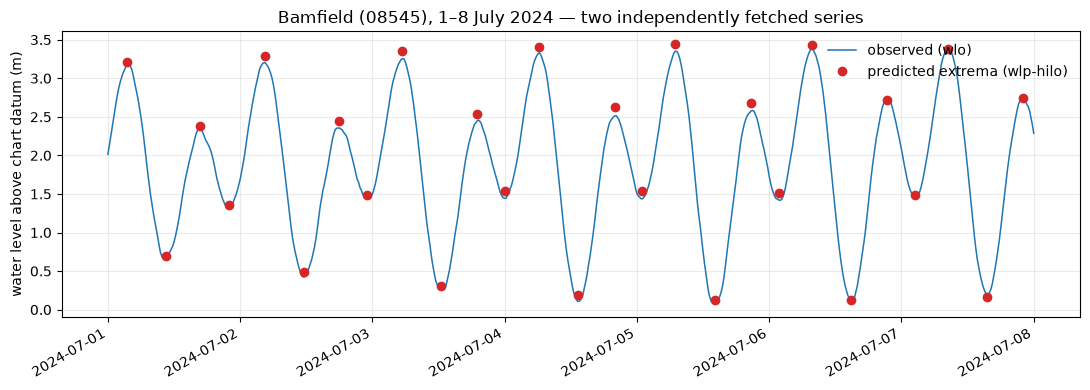

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(wlo.index, wlo.values, lw=1.1, label="observed (wlo)", color="#1f77b4")
ax.plot(hilo.index, hilo.values, "o", ms=6, label="predicted extrema (wlp-hilo)",
        color="#d62728", zorder=3)
ax.set_ylabel("water level above chart datum (m)")
ax.set_title("Bamfield (08545), 1–8 July 2024 — two independently fetched series")
ax.legend(loc="upper right", frameon=False)
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()

The red dots sit on the peaks and troughs of the blue line. That agreement is the real
end-to-end check: it means the times, the units *and* the datum are all right — not merely
parseable.

## 8. Many locations at once

Pass a list of `Site` objects — or `(lat, lon, name)` tuples, dicts, or a DataFrame with
`lat`/`lon` columns, so a CSV of moorings you already keep works without reshaping it.

Locations with no nearby data contribute nothing. That's normal, not an error — and
`coverage()` reports **every site you asked for**, so the gaps are visible rather than
inferred from an absence.

In [15]:
sites = [
    omnisea.Site(48.8353, -125.1358, "Bamfield",   radius_km=15),
    omnisea.Site(49.1530, -125.9066, "Tofino",     radius_km=15),
    omnisea.Site(48.4204, -123.3656, "Victoria",   radius_km=15),
    omnisea.Site(47.5000, -128.5000, "Open ocean", radius_km=15),   # deliberately empty
]

multi = omnisea.positions(sites, time=WEEK, providers="dfo_tides", nearest=1)
omnisea.coverage(multi)

,site,n_nodes,n_time,providers,has_data
0,Bamfield,2,699,dfo,True
1,Tofino,2,700,dfo,True
2,Victoria,2,691,dfo,True
3,Open ocean,0,0,,False


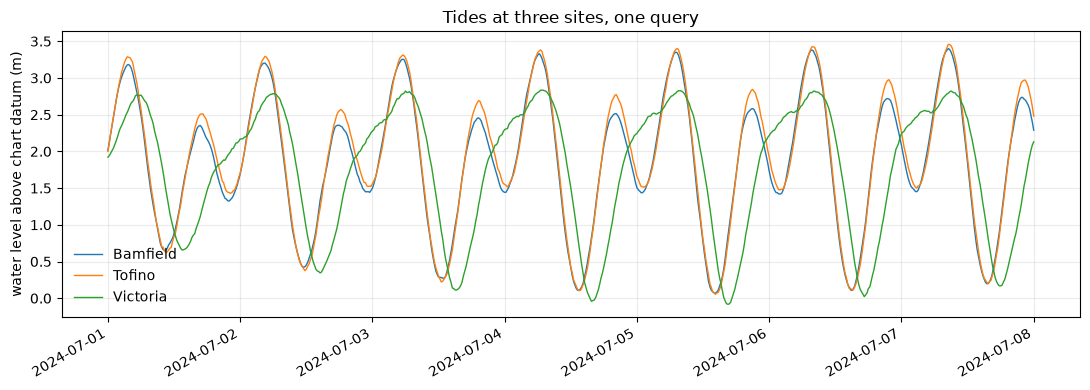

In [16]:
# your own site labels come back on the data, ready to join
tidy = omnisea.to_dataframe(multi)
obs = tidy[tidy["variable"] == "water_surface_height_above_reference_datum"]

fig, ax = plt.subplots(figsize=(11, 4))
for site, group in obs.groupby("site"):
    ax.plot(group["time"], group["value"], lw=1.0, label=site)
ax.set_ylabel("water level above chart datum (m)")
ax.set_title("Tides at three sites, one query")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()

## 9. Bring your own data and build a model

The tree is lossless but **ragged** — 15-minute tides, daily climate, irregular tidal extrema.
A model wants a rectangle.

Below is a mock five-day deployment: a logger in Bamfield Inlet sampling water temperature every
two hours.

> **The samples are synthetic**, generated from the *real* fetched drivers with coefficients we
> choose, plus noise. That makes this a test of the *pipeline* — if the join, the units and the
> time handling are right, a regression should recover the numbers we put in. It is not an
> oceanographic finding, and nothing here should be read as one.

In [17]:
import numpy as np

# real environmental drivers at the sample times
stamps = pd.date_range("2024-07-02 00:00", "2024-07-07 00:00", freq="2h")
drivers = omnisea.align(tree, on=pd.DataFrame({"time": stamps}), tolerance="30min")

tide    = drivers["water_surface_height_above_reference_datum"].to_numpy()
air_max = drivers["air_temperature_max"].to_numpy()
diurnal = np.sin(2 * np.pi * (drivers.index.hour.to_numpy() - 9) / 24)

# the relationship we are pretending governs this logger
TRUE = {
    "intercept": 6.00,
    "water_surface_height_above_reference_datum": -0.45,   # colder on the flood tide
    "air_temperature_max": 0.30,                           # warmer on hot days
    "hour_sin": 0.60,                                      # afternoon warming
}

rng = np.random.default_rng(42)
samples = pd.DataFrame({
    "time": drivers.index,
    "water_temp_c": (TRUE["intercept"]
                     + TRUE["water_surface_height_above_reference_datum"] * tide
                     + TRUE["air_temperature_max"] * air_max
                     + TRUE["hour_sin"] * diurnal
                     + rng.normal(0, 0.15, len(drivers))).round(2),
})
samples.head()

,time,water_temp_c
0,2024-07-02 00:00:00,9.96
1,2024-07-02 02:00:00,9.21
2,2024-07-02 04:00:00,9.20
3,2024-07-02 06:00:00,9.50
4,2024-07-02 08:00:00,9.83


### Join the environment onto the sample times

This is the part you would actually do with a real field sheet: one call, and every source lines
up on your timestamps.

In [18]:
data = omnisea.align(tree, on=samples, tolerance="30min")
data["hour_sin"] = np.sin(2 * np.pi * (data.index.hour - 9) / 24)

data[["water_temp_c", "water_surface_height_above_reference_datum",
      "air_temperature_max", "precipitation_amount", "hour_sin"]].head()

,water_temp_c,water_surface_height_above_reference_datum,air_temperature_max,precipitation_amount,hour_sin
time,,,,,
2024-07-02 00:00:00,9.96,1.690,17.0,0.0,-0.707107
2024-07-02 02:00:00,9.21,2.573,17.0,0.0,-0.965926
2024-07-02 04:00:00,9.20,3.185,17.0,0.0,-0.965926
2024-07-02 06:00:00,9.50,2.929,17.0,0.0,-0.707107
2024-07-02 08:00:00,9.83,1.837,17.0,0.0,-0.258819


In [19]:
# what each column had to do to get here
pd.Series(data.attrs["omnisea_aggregation"]).to_frame("how it was joined")

,how it was joined
water_surface_height_above_reference_datum@08545,nearest within 30min (61/61 matched)
reviewed@08545,nearest within 30min (61/61 matched)
air_temperature@1031316,backward within its own 1d interval (61/61 mat...
air_temperature_min@1031316,backward within its own 1d interval (61/61 mat...
air_temperature_max@1031316,backward within its own 1d interval (61/61 mat...
precipitation_amount@1031316,backward within its own 1d interval (61/61 mat...
rainfall_amount@1031316,backward within its own 1d interval (61/61 mat...
snowfall_amount@1031316,backward within its own 1d interval (61/61 mat...
surface_snow_thickness@1031316,nearest within 30min (6/61 matched)
cooling_degree_days@1031316,backward within its own 1d interval (61/61 mat...


### Fit a model

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

PREDICTORS = ["water_surface_height_above_reference_datum", "air_temperature_max", "hour_sin"]

X, y = data[PREDICTORS], data["water_temp_c"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

model = LinearRegression().fit(X_train, y_train)
predicted = model.predict(X_test)

print(f"held-out R2  = {r2_score(y_test, predicted):.3f}")
print(f"held-out MAE = {mean_absolute_error(y_test, predicted):.3f} degC")

held-out R2  = 0.975
held-out MAE = 0.135 degC


### Did it recover what we put in?

This is the real check. If the join were misaligned by the station's UTC offset, or the units
were silently converted, or a daily total had been interpolated, these numbers would not
match.

In [21]:
recovery = pd.DataFrame({
    "fitted": np.round(np.r_[model.intercept_, model.coef_], 3),
    "true":   [TRUE["intercept"]] + [TRUE[c] for c in PREDICTORS],
}, index=["intercept"] + PREDICTORS)
recovery["error"] = (recovery["fitted"] - recovery["true"]).round(3)
recovery

,fitted,true,error
intercept,5.969,6.00,-0.031
water_surface_height_above_reference_datum,-0.450,-0.45,0.000
air_temperature_max,0.301,0.30,0.001
hour_sin,0.586,0.60,-0.014


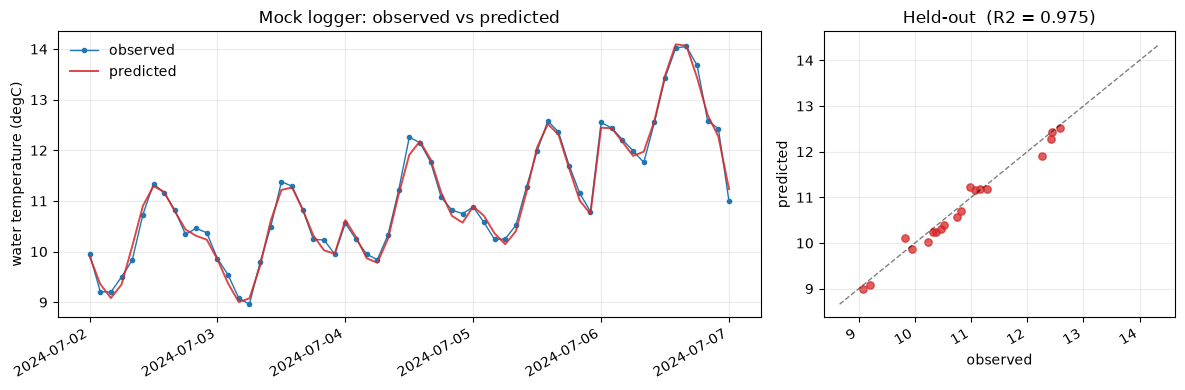

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4),
                               gridspec_kw={"width_ratios": [2, 1]})

ax1.plot(data.index, y, lw=1.0, marker="o", ms=3, label="observed", color="#1f77b4")
ax1.plot(data.index, model.predict(X), lw=1.4, label="predicted", color="#d62728", alpha=0.85)
ax1.set_ylabel("water temperature (degC)")
ax1.set_title("Mock logger: observed vs predicted")
ax1.legend(frameon=False)
ax1.grid(alpha=0.25)

ax2.scatter(y_test, predicted, s=28, color="#d62728", alpha=0.75)
lims = [min(y.min(), predicted.min()) - 0.3, max(y.max(), predicted.max()) + 0.3]
ax2.plot(lims, lims, "k--", lw=1, alpha=0.5)
ax2.set_xlabel("observed"); ax2.set_ylabel("predicted")
ax2.set_title(f"Held-out  (R2 = {r2_score(y_test, predicted):.3f})")
ax2.grid(alpha=0.25)

fig.autofmt_xdate()
plt.tight_layout()

### Or just throw in everything omnisea returned

Since every field comes back, you can hand the whole lot to the model and let it sort them out.

In [23]:
usable = [c for c in data.columns
          if c != "water_temp_c"
          and pd.api.types.is_numeric_dtype(data[c])
          and data[c].nunique() > 1]

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    data[usable].dropna(axis=1), y, test_size=0.3, random_state=0)
everything = LinearRegression().fit(Xa_train, ya_train)

print(f"{len(usable)} predictors -> R2 = {r2_score(ya_test, everything.predict(Xa_test)):.3f}")
print(f"3 chosen predictors -> R2 = {r2_score(y_test, predicted):.3f}")

7 predictors -> R2 = 0.973
3 chosen predictors -> R2 = 0.975


Almost the same predictive power — but the *coefficients* from the wide model are not
interpretable. `air_temperature`, `air_temperature_min`, `air_temperature_max` and
`heating_degree_days` all come from one station on one daily cadence, so they are near-collinear
and OLS splits the true effect arbitrarily among them.

That is a property of the data, not of the join — and it is exactly the kind of thing you can
only notice once everything is on one time axis in front of you.

omnisea can show you exactly which pairs those are — and prune the true duplicates.

### See the redundancy, then drop it

`omnisea.correlations()` is the collinearity evidence: every pair of features that moves
together, strongest first, with `n` — the overlapping samples each correlation was computed on,
because an r of 1.0 over three points is noise wearing a convincing costume. Compass directions
are excluded (a linear r between bearings is meaningless, the same reason `align()` combines
them as unit vectors), and so are QC flags.

In [24]:
omnisea.correlations(data, threshold=0.5)

,feature_a,feature_b,r,n
0,air_temperature,heating_degree_days,-1.000000,61
1,air_temperature_min,air_temperature_max,-0.840071,61
2,water_temp_c,air_temperature_max,0.785722,61
3,water_temp_c,air_temperature_min,-0.676746,61
4,water_surface_height_above_reference_datum,hour_sin,-0.614954,61
5,water_temp_c,hour_sin,0.544377,61
6,water_temp_c,water_surface_height_above_reference_datum,-0.532293,61


The rows naming `water_temp_c` are your response moving with its drivers — that is the model's
*signal*, and `drop_correlated()` ignores those pairs entirely: columns you carried through
`align(on=...)` are never dropped and never cause a drop.

Among the **features**, two findings that deserve different treatment. `heating_degree_days` is
*derived from* `air_temperature` (r = −1.0): a true duplicate, safe to drop mechanically. The
min/max pair is a real anti-correlation this particular week — two genuine measurements that
happen to move together, a modelling judgment rather than a duplication.

`drop_correlated()` automates only the part with a right answer: it walks the pairs strongest
first, keeps the better-covered column of each, and records every removal — auditable exactly
like the resampling choices in `omnisea_aggregation`.

In [25]:
pruned = omnisea.drop_correlated(data, threshold=0.9)
pd.Series(pruned.attrs["omnisea_dropped"]).to_frame("why it was dropped")

,why it was dropped
heating_degree_days,|r|=1.000 with air_temperature over 61 samples


When the near-copies are a judgment call rather than a duplication, `keep=` says which one you
trust, and its correlated partners go instead. We built the synthetic logger from
`air_temperature_max`, so pin that one and refit the everything-model on what survives:

In [26]:
lean = omnisea.drop_correlated(data, threshold=0.8, keep="air_temperature_max")

usable = [c for c in lean.columns
          if c != "water_temp_c"
          and pd.api.types.is_numeric_dtype(lean[c])
          and lean[c].nunique() > 1]
Xl_train, Xl_test, yl_train, yl_test = train_test_split(
    lean[usable].dropna(axis=1), lean["water_temp_c"], test_size=0.3, random_state=0)
leaner = LinearRegression().fit(Xl_train, yl_train)

print("dropped :", ", ".join(lean.attrs["omnisea_dropped"]))
print(f"{len(usable)} pruned predictors -> R2 = "
      f"{r2_score(yl_test, leaner.predict(Xl_test)):.3f}"
      f"   (everything model: {r2_score(ya_test, everything.predict(Xa_test)):.3f})")

dropped : heating_degree_days, air_temperature_min
5 pruned predictors -> R2 = 0.975   (everything model: 0.973)


Same predictive power from fewer, non-duplicated features — and no coefficient is being split
across near-copies of itself any more. The whole decision trail travels on the frame:
`attrs["omnisea_aggregation"]` says how each column was joined, `attrs["omnisea_dropped"]` says
what was removed and why.

Different tidal ranges and phases along the coast — Barkley Sound versus the Strait of
Juan de Fuca — from a single call.

## 10. Save it

`DataTree.to_netcdf()` works natively via netCDF4 groups. The structure round-trips.

In [27]:
import xarray as xr

tree.to_netcdf("bamfield.nc")
reopened = xr.open_datatree("bamfield.nc")
[n.path for n in reopened.subtree if n.dataset.data_vars]

['/in_situ/tides/08545',
 '/in_situ/weather_daily/1031316',
 '/predictions/tides_hilo/08545']

---

## Adding your own source

A new data source is **one new file**, not a refactor — see
[`docs/adding-a-provider.md`](../docs/adding-a-provider.md) and the worked example in
[`examples/csv_stations.py`](csv_stations.py).

Ship it as a package with an entry point and it's indexed automatically:

```toml
[project.entry-points."omnisea.providers"]
my_org = "my_package.provider:MyOrgProvider"
```